## Visualização

Nesse notebook são produzidas as visualizações dos dados

In [ ]:
import matplotlib.pyplot as plt
import mapclassify
import math
from pyproj import Transformer
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Rectangle, Polygon, Patch
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
from utils.load_shp import load_shp
from utils.load_csv import load_csv
from utils.save_graph import save_graph

In [117]:
mapa = load_shp("mapa.shp")

dados = load_csv("dados.csv")

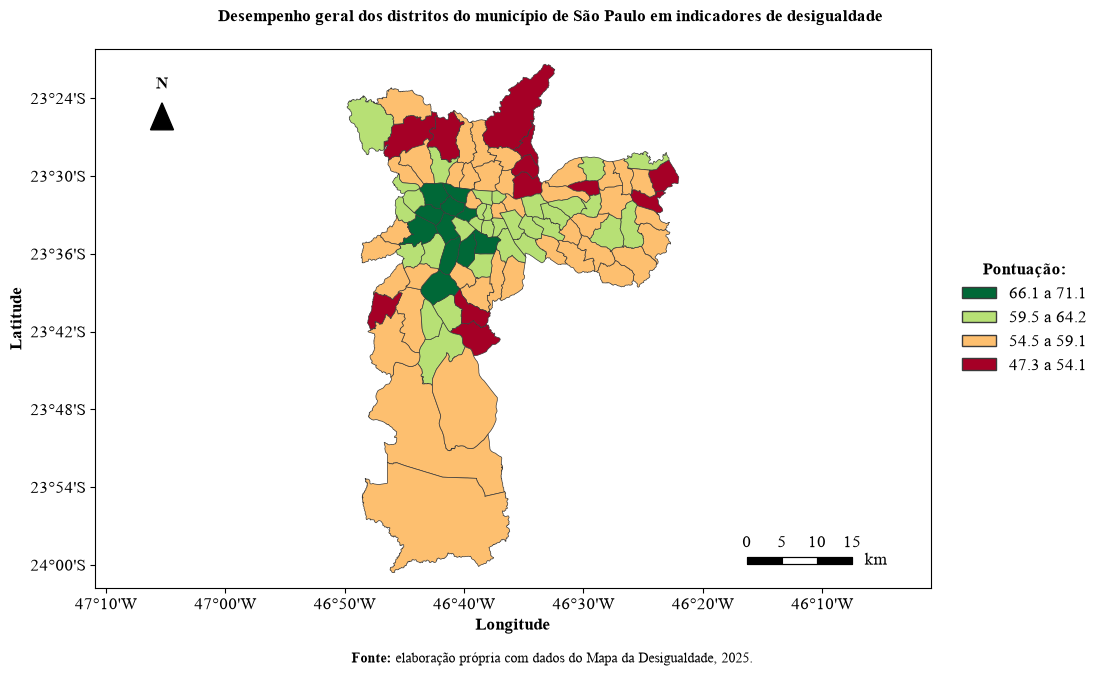

In [118]:
para_graus = Transformer.from_crs(mapa.crs, "EPSG:4326", always_xy=True)
para_metros = Transformer.from_crs("EPSG:4326", mapa.crs, always_xy=True)

K = 4
classificador = mapclassify.NaturalBreaks(mapa["pontuacao"], k=K)
mapa["classe"] = classificador.yb

cmap_seq = plt.get_cmap("RdYlGn")
cores = [cmap_seq(i / (K - 1)) for i in range(K)]
mapa["cor"] = mapa["classe"].map(lambda i: cores[i])

labels_classe = []
for i in range(K):
    vals = mapa.loc[mapa["classe"] == i, "pontuacao"]
    labels_classe.append(f"{vals.min():.1f} a {vals.max():.1f}")

def passo_legal_minutos(span_graus, target_ticks=6):
    span_min = span_graus * 60
    candidatos = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30, 60]
    return min(candidatos, key=lambda c: abs(span_min / c - target_ticks))

def ticks_redondos(vmin, vmax, passo_min):
    passo_deg = passo_min / 60
    v = math.ceil(vmin / passo_deg) * passo_deg
    out = []
    while v <= vmax + 1e-9:
        out.append(round(v, 10))
        v += passo_deg
    return out

def configurar_eixos_geograficos(ax, transformer_metros, target_ticks_x=6, target_ticks_y=6):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x_centro, y_centro = (xlim[0] + xlim[1]) / 2, (ylim[0] + ylim[1]) / 2
    lon_centro, lat_centro = para_graus.transform(x_centro, y_centro)

    cantos_x = [xlim[0], xlim[0], xlim[1], xlim[1]]
    cantos_y = [ylim[0], ylim[1], ylim[0], ylim[1]]
    lons, lats = para_graus.transform(cantos_x, cantos_y)
    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)

    passo_lon = passo_legal_minutos(lon_max - lon_min, target_ticks_x)
    passo_lat = passo_legal_minutos(lat_max - lat_min, target_ticks_y)

    lons_tick = ticks_redondos(lon_min, lon_max, passo_lon)
    lats_tick = ticks_redondos(lat_min, lat_max, passo_lat)

    xs_tick, _ = transformer_metros.transform(lons_tick, [lat_centro] * len(lons_tick))
    _, ys_tick = transformer_metros.transform([lon_centro] * len(lats_tick), lats_tick)

    def fmt_lon(v):
        g = int(abs(v)); m = int(round((abs(v) - g) * 60))
        if m == 60: g, m = g + 1, 0
        return f"{g}°{m:02d}'W"

    def fmt_lat(v):
        g = int(abs(v)); m = int(round((abs(v) - g) * 60))
        if m == 60: g, m = g + 1, 0
        return f"{g}°{m:02d}'S"

    ax.set_xticks(xs_tick)
    ax.set_xticklabels([fmt_lon(v) for v in lons_tick])
    ax.set_yticks(ys_tick)
    ax.set_yticklabels([fmt_lat(v) for v in lats_tick])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

def add_north_arrow(ax, x, y, size=0.05):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    largura_x, altura_y = xlim[1] - xlim[0], ylim[1] - ylim[0]
    x_data = xlim[0] + x * largura_x
    y_data = ylim[0] + y * altura_y
    seta_altura = altura_y * size
    seta_largura = largura_x * size * 0.55

    triangulo = Polygon(
        [
            (x_data, y_data + seta_altura),
            (x_data - seta_largura / 2, y_data),
            (x_data + seta_largura / 2, y_data),
        ],
        closed=True, facecolor="black", edgecolor="black", zorder=5
    )
    ax.add_patch(triangulo)
    ax.text(
        x_data, y_data + seta_altura + altura_y * 0.02, "N",
        ha="center", va="bottom", fontsize=12, fontweight="bold", zorder=5
    )

def add_scale_bar(ax, length_km, location=(0.8, 0.045), height_frac=0.012):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    largura_x, altura_y = xlim[1] - xlim[0], ylim[1] - ylim[0]
    x0 = xlim[0] + location[0] * largura_x
    y0 = ylim[0] + location[1] * altura_y
    h = altura_y * height_frac

    comprimento_m = length_km * 1000
    n_blocos = 3
    bloco = comprimento_m / n_blocos

    for i in range(n_blocos):
        cor = "black" if i % 2 == 0 else "white"
        ax.add_patch(Rectangle(
            (x0 + i * bloco, y0), bloco, h,
            facecolor=cor, edgecolor="black", linewidth=0.8, zorder=5
        ))
    ax.add_patch(Rectangle(
        (x0, y0), comprimento_m, h,
        fill=False, edgecolor="black", linewidth=0.8, zorder=6
    ))
    for i in range(n_blocos + 1):
        valor = int(round(i * length_km / n_blocos))
        ax.text(
            x0 + i * bloco, y0 + h + altura_y * 0.012, f"{valor}",
            ha="center", va="bottom", fontsize=12, zorder=6
        )
    ax.text(
        x0 + comprimento_m + largura_x * 0.015, y0 + h / 2, "km",
        ha="left", va="center", fontsize=12, zorder=6
    )

def centralizar_em_caixa_horizontal(ax, mapa, target_ratio=1.55, margem=0.06):
    minx, miny, maxx, maxy = mapa.total_bounds
    dx, dy = maxx - minx, maxy - miny

    dx_pad = dx * (1 + margem)
    dy_pad = dy * (1 + margem)

    largura_alvo = dy_pad * target_ratio
    if largura_alvo > dx_pad:
        extra = (largura_alvo - dx_pad) / 2
        xlim = (minx - dx * margem / 2 - extra, maxx + dx * margem / 2 + extra)
        ylim = (miny - dy * margem / 2, maxy + dy * margem / 2)
    else:
        altura_alvo = dx_pad / target_ratio
        extra = (altura_alvo - dy_pad) / 2
        xlim = (minx - dx * margem / 2, maxx + dx * margem / 2)
        ylim = (miny - dy * margem / 2 - extra, maxy + dy * margem / 2 + extra)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif"]

fig, ax = plt.subplots(figsize=(13, 7))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

mapa.plot(
    color=mapa["cor"],
    linewidth=0.5,
    edgecolor="#3a3a3a",
    ax=ax,
)

ax.set_aspect("equal") 
centralizar_em_caixa_horizontal(ax, mapa, target_ratio=1.55, margem=0.06)
fig.canvas.draw()

handles = [Patch(facecolor=cores[i], edgecolor="#3a3a3a") for i in range(K)]
ax.legend(
    handles[::-1], labels_classe[::-1],
    title="Pontuação:",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=12,
    title_fontproperties={"size": 12, "weight": "bold"}
)

add_north_arrow(ax, x=0.08, y=0.85, size=0.05)
add_scale_bar(ax, length_km=15, location=(0.78, 0.045))
configurar_eixos_geograficos(ax, para_metros, target_ticks_x=7, target_ticks_y=7)

ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Longitude", fontsize=12, fontweight="bold")
ax.set_ylabel("Latitude", fontsize=12, fontweight="bold")

ax.set_title(
    "Desempenho geral dos distritos do município de São Paulo em indicadores de desigualdade",
    fontsize=12, fontweight="bold", pad=20, x=0.545
)

texto_negrito = TextArea("Fonte: ", textprops=dict(fontsize=10, fontweight="bold", color="black"))
texto_normal = TextArea(
    "elaboração própria com dados do Mapa da Desigualdade, 2025.",
    textprops=dict(fontsize=10, fontweight="normal", color="black")
)
caixa_fonte = HPacker(children=[texto_negrito, texto_normal], align="center", pad=0, sep=0)
ab = AnnotationBbox(
    caixa_fonte, (0.425, 0.02), xycoords="figure fraction",
    box_alignment=(0.5, 0.5), frameon=False
)
fig.add_artist(ab)

save_graph(fig, "mapa_desigualdade")
plt.show()

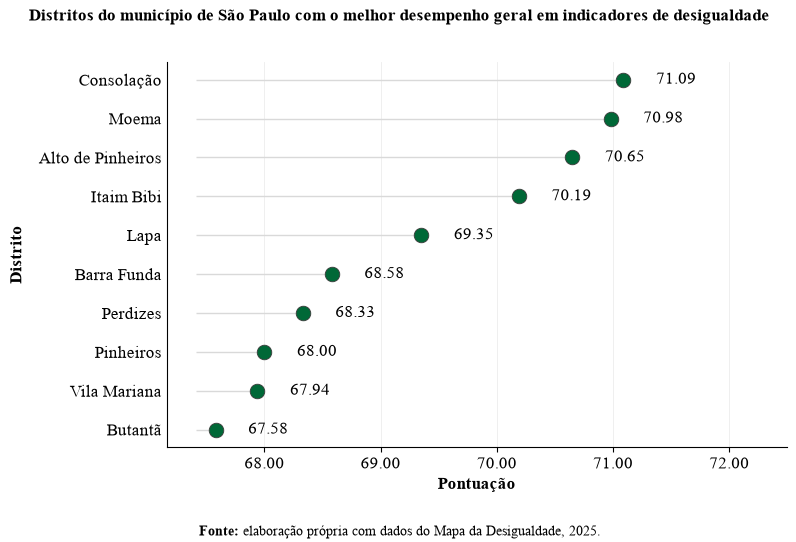

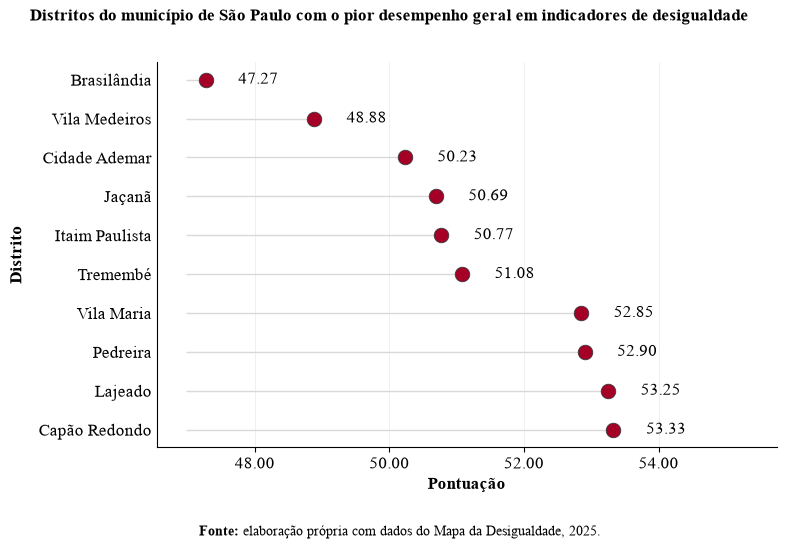

In [119]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif"
]

ranking = (
    dados[["distrito", "pontuacao"]]
    .sort_values("pontuacao", ascending=False)
    .reset_index(drop=True)
)

top10 = ranking.head(10).copy()

bottom10 = (
    ranking.tail(10)
    .sort_values("pontuacao", ascending=True)
    .reset_index(drop=True)
)

cmap_seq = plt.get_cmap("RdYlGn")

cor_verde_escuro = cmap_seq(1.0)
cor_vermelho_escuro = cmap_seq(0.0)

def painel(ax, dados_painel, cor, titulo, titulo_x=0.5, titulo_pad=14):

    ax.set_facecolor("white")

    xmin = dados_painel["pontuacao"].min()
    xmax = dados_painel["pontuacao"].max()
    offset = (xmax - xmin) * 0.08 if xmax != xmin else xmax * 0.02

    ax.hlines(
        y=range(len(dados_painel)),
        xmin=xmin - offset * 0.6,
        xmax=dados_painel["pontuacao"],
        color="#d9d9d9",
        linewidth=1
    )

    ax.scatter(
        dados_painel["pontuacao"],
        range(len(dados_painel)),
        s=110,
        color=cor,
        edgecolor="#3a3a3a",
        linewidth=0.6,
        zorder=3
    )

    for y, valor in enumerate(dados_painel["pontuacao"]):
        ax.text(
            valor + offset,
            y,
            f"{valor:.2f}",
            va="center",
            fontsize=12
        )

    ax.set_yticks(range(len(dados_painel)))
    ax.set_yticklabels(dados_painel["distrito"], fontsize=12)
    ax.invert_yaxis()

    ax.grid(axis="x", color="#ececec", linewidth=0.6)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=12)

    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.set_xlim(xmin - offset * 1.5, xmax + offset * 5)

    ax.set_xlabel("Pontuação", fontsize=12, fontweight="bold")
    ax.set_ylabel("Distrito", fontsize=12, fontweight="bold", labelpad=10)

    ax.set_title(
        titulo,
        fontsize=12,
        fontweight="bold",
        pad=titulo_pad,
        x=titulo_x
    )

def adicionar_fonte(fig, y=0.02):
    texto_negrito = TextArea(
        "Fonte: ",
        textprops=dict(fontsize=10, fontweight="bold", color="black")
    )
    texto_normal = TextArea(
        "elaboração própria com dados do Mapa da Desigualdade, 2025.",
        textprops=dict(fontsize=10, fontweight="normal", color="black")
    )
    caixa_fonte = HPacker(children=[texto_negrito, texto_normal], align="center", pad=20, sep=0)
    ab = AnnotationBbox(
        caixa_fonte, (0.5, y), xycoords="figure fraction",
        box_alignment=(0.5, 0.5), frameon=False
    )
    fig.add_artist(ab)

fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.patch.set_facecolor("white")

painel(
    ax1,
    top10,
    cor_verde_escuro,
    "Distritos do município de São Paulo com o melhor desempenho geral em indicadores de desigualdade",
    titulo_x=0.375,
    titulo_pad=30
)

adicionar_fonte(fig1, y=0.02)

save_graph(fig1, "ranking_top10_desigualdade")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.patch.set_facecolor("white")

painel(
    ax2,
    bottom10,
    cor_vermelho_escuro,
    "Distritos do município de São Paulo com o pior desempenho geral em indicadores de desigualdade",
    titulo_x=0.375,
    titulo_pad=30
)

adicionar_fonte(fig2, y=0.02)

save_graph(fig2, "ranking_bottom10_desigualdade")
plt.show()